[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/07_industry_applications/A4_causal_uplift.ipynb)

> 📎 **Appendix notebook — full-lesson style.** Module 7's fourth appendix (see `README.md`), written like the module's core notebooks: same rhythm, same ✋/🧪/🧠 ladder. It runs on the core course stack (`numpy`, `pandas`, `scikit-learn`, `matplotlib`, `seaborn`) with all data generated inline — 100 % offline.

---
# 📓 Notebook A4 (IA) — Causal Inference & Uplift: Who to Target, Not Who Will Churn

> **Module:** Industry Applications · **Type:** Appendix · **Estimated time:** ~2 h 45 m · **Difficulty:** ⭐⭐ (stretch ⭐⭐⭐)

NB 23 ended on a warning it never resolved: *"$p_i$ measures risk, not persuadability"* — and its Stretch B sketched a two-model uplift estimator in twenty lines and moved on. A2 told you how to measure an **average** effect honestly. This notebook is the missing third act: the average effect of a retention offer is nearly useless for *deciding who gets it*, because the same offer **saves** some customers, is **wasted** on most, and actively **pushes a few out the door**.

And there is a second, sharper problem underneath: most of the data a business has about its own campaigns was produced by *targeting*, not by chance. Estimating what a campaign did from data where the riskiest customers were deliberately the ones treated is the single most common way analytics teams fool themselves.

> 🧠 **Mental model.** A causal question is a comparison between **two worlds** — this customer with the offer, this customer without — and you only ever get to see one of them. Everything in this notebook is a strategy for filling in the world you didn't see: randomize (§3), model who reacts (§4), find a clean natural comparison (§5), or adjust and pray your confounders are all measured (§6). The methods differ in cost; they also differ in how loudly they fail.

## 🎯 Learning objectives

By the end you can:

1. Write a campaign question in **potential-outcomes** language (`y0`, `y1`), and decompose a naive treated-vs-untreated comparison into **effect + selection bias** — numerically, not just on a slide.
2. Name the four uplift segments — **persuadables, sure things, lost causes, sleeping dogs** — and price each one in euros for a given offer.
3. Fit and honestly evaluate a **two-model (T-learner) uplift model** on randomized data, and use the **break-even uplift** to decide how deep to target.
4. Estimate a rollout's effect with **difference-in-differences** when there was no experiment, check parallel trends, and run a placebo test.
5. Use **regression adjustment / IPW** on targeted (observational) data — and demonstrate exactly when they work and when an unmeasured confounder silently breaks them.
6. Say which quarter's data can answer which question — the skill that keeps a retention program from being run on fiction.

## ✅ Prerequisites

**NB 23** (churn economics, retention targeting — this notebook is its direct sequel) and **A2** (experiments; we lean on its "measuring instrument" frame). **NB 18**'s honest-evaluation habits are assumed throughout. **NB 10** for confidence intervals. All data is generated inline; everything runs offline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

V = 180.0   # value of a retained subscriber (remaining CLV, EUR -- NB 23 style)
D = 9.50    # discount cost, paid if a treated customer stays (1 month at 50% off EUR 19)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

print(f"A saved customer is worth EUR {V:.0f}; the offer costs EUR {D:.2f} per treated customer who stays.")

A saved customer is worth EUR 180; the offer costs EUR 9.50 per treated customer who stays.


## 1. The business, and a campaign report that smells wrong

**Brightloop** sells a €19/month subscription analytics tool. Churn runs at roughly 23 % per quarter, so the retention team acts: last quarter it pulled the churn scores from Brightloop's NB 17-style model and offered a **one-month 50 % discount** to the customers at the top of the risk list. Coverage was patchy — capacity varied week to week, so plenty of high-risk customers were missed and a few low-risk ones got the offer anyway. (Keep that detail; it will matter in §6.)

The quarter ends. The analyst compares churn between customers who got the offer and customers who didn't, and the report lands on your desk:

> *"Customers who received the discount churned **more** than customers who didn't. The offer appears to have slightly backfired; we recommend discontinuing the program."*

Before accepting a conclusion that expensive, let's rebuild the quarter from the ground up. Because we *simulate* Brightloop's customers, we get a superpower no analyst has in production: for every customer we will know **both** potential outcomes — what they'd do with the offer *and* without it. That god-mode view is the fastest way to understand exactly how the report above goes wrong, and it is the standard trick for studying causal methods (you check the estimator against a truth you control).

In [2]:
def build_customers(n, seed):
    """One quarter of Brightloop customers, with BOTH potential outcomes.

    y0 = would they churn this quarter WITHOUT the offer?
    y1 = would they churn this quarter WITH the offer?
    In production you observe exactly one of the two -- never both.
    """
    rng = np.random.default_rng(seed)
    tenure = rng.gamma(2.2, 11, n).clip(1, 96)            # months as a customer
    usage = rng.gamma(2.0, 4.0, n).clip(0.1, 60)          # hours of use / month
    tickets = rng.poisson(0.8, n)                         # support tickets this quarter
    promo_signup = rng.random(n) < 0.35                   # joined on a promotional price
    spend = np.where(rng.random(n) < 0.7, 19.0, 29.0)     # plan (EUR/month)

    # ---- baseline churn probability WITHOUT the offer ----
    # The rng.normal() term is risk the company never measures (mood, a
    # competitor's cold call, a budget review) -- keep it in mind for §6.
    z0 = (-1.15 - 0.045 * usage + 0.38 * tickets - 0.012 * tenure
          + 0.55 * promo_signup + rng.normal(0, 0.35, n))
    p0 = sigmoid(z0).clip(0.01, 0.95)

    # ---- what the offer does to that probability ----
    # Price-sensitive customers at moderate risk are PERSUADED to stay;
    # dormant long-tenure customers are REMINDED they still pay -- the email
    # itself pushes some of them to cancel ("sleeping dogs", NB 23 SS4).
    persuadable = promo_signup * sigmoid(1.1 * (p0 - 0.18) / 0.10)
    dormant = sigmoid((6 - usage) / 1.5) * sigmoid((tenure - 24) / 8.0)
    tau = -0.30 * persuadable + 0.22 * dormant + rng.normal(0, 0.01, n)
    p1 = (p0 + tau).clip(0.005, 0.97)

    df = pd.DataFrame(dict(
        tenure=tenure.round(0), usage=usage.round(1), tickets=tickets,
        promo_signup=promo_signup.astype(int), spend=spend, p0=p0, p1=p1))
    u = rng.random(n)                       # one shared draw couples the two worlds
    df["y0"] = (u < p0).astype(int)
    df["y1"] = (u < p1).astype(int)
    return df

df = build_customers(20_000, seed=42)
FEATURES = ["tenure", "usage", "tickets", "promo_signup", "spend"]
df[FEATURES + ["y0", "y1"]].head()

,tenure,usage,tickets,promo_signup,spend,y0,y1
0,25.0,6.3,1,0,19.0,1,1
1,34.0,1.7,0,1,29.0,0,0
2,23.0,6.5,1,0,19.0,0,0
3,20.0,7.8,1,1,29.0,1,0
4,37.0,8.6,2,1,19.0,0,0


In [3]:
# ---- last quarter: the risk-targeted campaign, reconstructed ----
# The old model was fitted on observed features, so its score is a (noisy)
# function of OBSERVABLES only. The team worked down the risk list with
# patchy capacity -> treatment probability rises steeply with the score but
# never hits 0 or 1.
rng = np.random.default_rng(43)
z_obs = (-1.15 - 0.045 * df.usage + 0.38 * df.tickets
         - 0.012 * df.tenure + 0.55 * df.promo_signup)
risk_score = sigmoid(z_obs + rng.normal(0, 0.10, len(df))).to_numpy()

obs = df.iloc[:8000].copy()                       # last quarter's book
cut = np.quantile(risk_score[:8000], 0.60)
p_treat = sigmoid(10 * (risk_score[:8000] - cut)).clip(0.05, 0.95)
obs["treated"] = (rng.random(len(obs)) < p_treat).astype(int)
obs["churned"] = np.where(obs.treated == 1, obs.y1, obs.y0)   # you see ONE world

report = obs.groupby("treated")["churned"].agg(["mean", "count"])
naive = report.loc[1, "mean"] - report.loc[0, "mean"]
print(report.rename(index={0: "no offer", 1: "offer"}).round(3))
print(f"\nnaive comparison: {naive * 100:+.1f} pp -- 'the offer increased churn'")

           mean  count
treated               
no offer  0.194   4191
offer     0.213   3809

naive comparison: +1.8 pp -- 'the offer increased churn'


There it is: **+1.8 pp**. Treated customers really did churn more — the report's *arithmetic* is fine. The question is whether the offer *caused* that. The treated group wasn't a random slice of the base; it was, by construction, **the risk list**. We're comparing risky-people-with-offer against safe-people-without and attributing the whole gap to the offer.

You've met this failure before — NB 24's selective labels, A3 §6's approved-only book. It's the same disease in campaign clothing. To say precisely what's wrong, we need two columns the analyst never sees.

## 2. Potential outcomes — the two-worlds bookkeeping

For customer $i$, write $y_i(0)$ for whether they churn **without** the offer and $y_i(1)$ for whether they churn **with** it. The offer's effect on $i$ is the difference between two worlds:

$$\tau_i = y_i(1) - y_i(0) \in \{-1, 0, +1\}$$

Nobody observes $\tau_i$ — you get one world per customer. That is the **fundamental problem of causal inference**, and every method in this notebook is a workaround for it. But in our simulation both columns exist, so for once we can just *look*. Crossing the two binary outcomes gives the four uplift segments (NB 23 §4 named them; now we can count and **price** them):

| | stays with offer ($y_1{=}0$) | churns with offer ($y_1{=}1$) |
|---|---|---|
| **would churn without** ($y_0{=}1$) | 😍 **Persuadable** — the offer saves them: **+€170.50** | 🪦 **Lost cause** — leaves either way: **€0** (offer unpaid — they're gone) |
| **would stay without** ($y_0{=}0$) | 😐 **Sure thing** — pays for nothing: **−€9.50** | 🐕 **Sleeping dog** — the offer *causes* the loss: **−€180** |

The euro values follow from §1's economics: a save is worth $V - D = 180 - 9.50$, a sure thing costs you the discount $D$, and waking a sleeping dog costs the whole customer, $V$. Targeting is the art of buying persuadables without paying for the other three boxes.

In [4]:
def segment(d):
    return pd.Series(np.select(
        [(d.y0 == 1) & (d.y1 == 0), (d.y0 == 0) & (d.y1 == 0),
         (d.y0 == 1) & (d.y1 == 1), (d.y0 == 0) & (d.y1 == 1)],
        ["persuadable", "sure thing", "lost cause", "sleeping dog"],
        default="?"), index=d.index)

seg = segment(df)
shares = seg.value_counts(normalize=True)
print(shares.round(3).to_string())

true_ate = (df.p1 - df.p0).mean()
print(f"\ntrue average effect of offering EVERYONE (ATE): {true_ate * 100:+.1f} pp of churn")

sure thing      0.742
lost cause      0.167
persuadable     0.060
sleeping dog    0.030

true average effect of offering EVERYONE (ATE): -3.0 pp of churn


Three numbers to sit with:

- The offer is genuinely good **on average** — it cuts churn by ~3 pp if given to everyone.
- But **~74 %** of the base are sure things: for them the offer is a pure €9.50 gift. Another ~17 % are lost causes.
- Only **~6 %** are persuadables — and ~3 % are sleeping dogs, where the "retention" email is the thing that *causes* the cancellation.

The average hides a fight between a small group the offer saves and a smaller group it destroys, on top of a large majority where it just burns margin. Now we can also dissect last quarter's report with surgical precision, because the naive comparison decomposes *exactly* (no approximation) into:

$$\underbrace{\mathbb{E}[y \mid T{=}1] - \mathbb{E}[y \mid T{=}0]}_{\text{naive}} \;=\; \underbrace{\mathbb{E}[y_1 - y_0 \mid T{=}1]}_{\text{real effect on the treated (ATT)}} \;+\; \underbrace{\mathbb{E}[y_0 \mid T{=}1] - \mathbb{E}[y_0 \mid T{=}0]}_{\text{selection bias}}$$

The second term asks: *ignoring the offer entirely, how much churn-ier were the people the team chose to treat?* For a risk-targeted campaign that term is large and positive by design.

In [5]:
t1, t0 = obs[obs.treated == 1], obs[obs.treated == 0]
att = (t1.y1 - t1.y0).mean()                    # real effect on the treated
sel_bias = t1.y0.mean() - t0.y0.mean()          # how much churn-ier the treated already were

print(f"naive comparison    : {naive * 100:+.2f} pp")
print(f"= real effect (ATT) : {att * 100:+.2f} pp   <- the offer HELPED the treated")
print(f"+ selection bias    : {sel_bias * 100:+.2f} pp   <- ...but they were riskier to begin with")
print(f"  check: {att * 100:+.2f} + {sel_bias * 100:+.2f} = {(att + sel_bias) * 100:+.2f}")

naive comparison    : +1.85 pp
= real effect (ATT) : -5.43 pp   <- the offer HELPED the treated
+ selection bias    : +7.28 pp   <- ...but they were riskier to begin with
  check: -5.43 + +7.28 = +1.85


The offer cut churn among the treated by **5.4 pp** — it *worked* — and a **+7.3 pp** helping of selection bias flipped the sign in the report. The team was about to cancel a program that makes money, on the strength of arithmetic that was perfectly correct.

> ⚠️ **This is the most common analytics failure in industry.** Any time treatment went to whoever *needed it most* — discounts to risky customers, training to weak sales reps, maintenance to fragile machines (NB 26) — the naive comparison is biased against the treatment. The reverse happens when treatment goes to the *best* cases (new features to power users). The sign of the bias is the sign of the targeting.

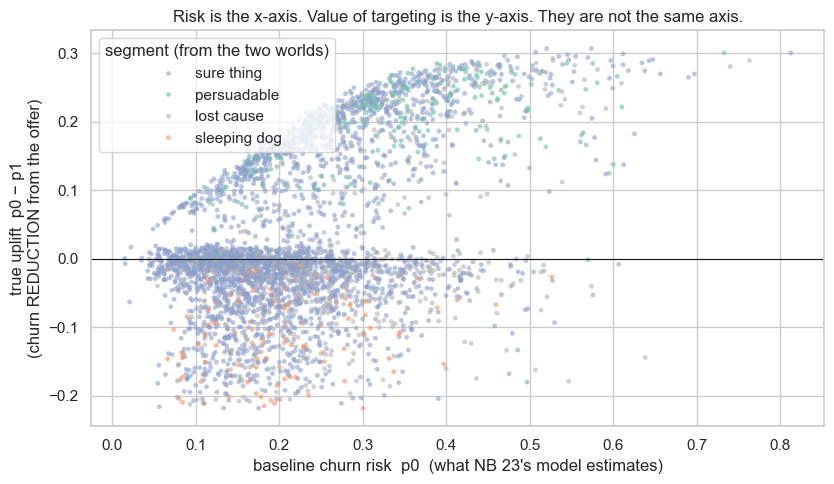

In [6]:
# FIG 1 -- the four segments in risk/effect space
fig, ax = plt.subplots(figsize=(8.5, 5))
show = df.sample(4000, random_state=0)
palette = {"sure thing": "#8da0cb", "lost cause": "#b3b3b3",
           "persuadable": "#66c2a5", "sleeping dog": "#fc8d62"}
sns.scatterplot(x=show.p0, y=(show.p0 - show.p1), hue=segment(show), palette=palette,
                s=12, alpha=0.6, ax=ax, edgecolor="none")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("baseline churn risk  p0  (what NB 23's model estimates)")
ax.set_ylabel("true uplift  p0 − p1\n(churn REDUCTION from the offer)")
ax.set_title("Risk is the x-axis. Value of targeting is the y-axis. They are not the same axis.")
ax.legend(title="segment (from the two worlds)", loc="upper left")
plt.tight_layout()

Read the picture the way the retention team should: NB 23's model sorts customers **left to right** (risk). Money is made **bottom to top** (uplift). The far right — where a risk-targeted campaign spends its budget — is dominated by lost causes at $\text{uplift} \approx 0$. The sleeping dogs sit *below* zero at low-to-mid risk, exactly where "call everyone just in case" does its damage.

---

### ✋ Quick exercise (~2 min) — price these four customers

For each row, classify the segment and compute the profit (in €, using `V` and `D`) of **including them in the campaign** versus leaving them alone:

| customer | y0 | y1 |
|---|---|---|
| a | 1 | 0 |
| b | 0 | 0 |
| c | 1 | 1 |
| d | 0 | 1 |

In [7]:
# ✍️ Your turn 👇
# segment + euro value of TARGETING each of: (y0=1,y1=0), (0,0), (1,1), (0,1)
# remember: the discount D is only paid if the treated customer STAYS (y1=0)

<details>
<summary>✅ <b>Solution</b></summary>

```python
for name, y0_, y1_ in [("a", 1, 0), ("b", 0, 0), ("c", 1, 1), ("d", 0, 1)]:
    label = {(1, 0): "persuadable", (0, 0): "sure thing",
             (1, 1): "lost cause", (0, 1): "sleeping dog"}[(y0_, y1_)]
    value = V * (y0_ - y1_) - D * (1 - y1_)
    print(f"{name}: {label:12s} -> {value:+8.2f} EUR")
```

`a` is the persuadable: you keep €180 of CLV and pay the €9.50 discount → **+170.50**. `b` stays anyway, so you pay €9.50 for nothing. `c` leaves anyway — and never sticks around to collect the discount → **0**. `d` is the expensive one: −€180, caused entirely by your own campaign. One formula covers all four: $V(y_0 - y_1) - D(1 - y_1)$ — worth keeping, because §4's policy comparison is just this formula summed over whoever you choose to call.
</details>

## 3. This quarter: randomize, and the bias term dies

The fix for selection bias is brutally simple and costs one quarter of discipline: **let a coin decide** who gets the offer. Randomization makes $T$ independent of *everything* — including $y_0$ — so the selection term $\mathbb{E}[y_0|T{=}1] - \mathbb{E}[y_0|T{=}0]$ is zero *by construction*, not by assumption. The naive comparison suddenly *is* the causal effect. That is the entire magic of the RCT, and it's why A2 spent a whole notebook protecting it.

Brightloop runs this quarter's campaign as an A/B test on the other 12,000 customers: a fair coin per customer.

In [8]:
rct = df.iloc[8000:].copy().reset_index(drop=True)   # this quarter's book
rng2 = np.random.default_rng(44)
rct["treated"] = (rng2.random(len(rct)) < 0.5).astype(int)
rct["churned"] = np.where(rct.treated == 1, rct.y1, rct.y0)

g = rct.groupby("treated")["churned"]
est = g.mean()[1] - g.mean()[0]
se = np.sqrt(g.var()[1] / g.count()[1] + g.var()[0] / g.count()[0])
sel_rct = (rct.loc[rct.treated == 1, "y0"].mean()
           - rct.loc[rct.treated == 0, "y0"].mean())

print(f"RCT estimate : {est * 100:+.2f} pp  (95% CI ± {1.96 * se * 100:.2f} pp)")
print(f"true ATE     : {true_ate * 100:+.2f} pp")
print(f"selection term this time: {sel_rct * 100:+.2f} pp  (randomization ~zeroed it)")

RCT estimate : -4.27 pp  (95% CI ± 1.46 pp)
true ATE     : -3.04 pp
selection term this time: -1.38 pp  (randomization ~zeroed it)


**−4.3 pp ± 1.5** — the CI covers the truth, and the selection term collapsed from +7.3 pp to **−1.4 pp** — pure sampling wobble now (its *expected* value is zero by design; what's left is the same ±1.5 pp noise the CI already prices in). One A2 habit before moving on: this test's MDE at these sample sizes is ≈2 pp of churn, finer than the ~3 pp effect we'd need to act on — the instrument resolves the question we're asking. Always check that *before* the quarter, not after.

So the *program-level* question is settled: the offer works on average. But §2 showed the average is a fight between segments. Giving the discount to all 74 % sure things to reach 6 % persuadables is how a causally-effective program still loses money — what we actually want is each customer's $\tau_i$. Time to model it.

## 4. Uplift modeling — estimating *who* reacts

We can't observe $\tau_i$, but with randomized data we can estimate $\mathbb{E}[\tau \mid x]$: **among customers who look like $x$**, the treated and control groups are exchangeable, so the churn gap between them *at that $x$* is a fair estimate of the offer's effect *for that kind of customer*.

The simplest implementation is the **two-model / T-learner** you sketched in NB 23 Stretch B: fit one churn model on the treated arm, one on the control arm, and subtract:

$$\widehat{\text{uplift}}(x) = \hat p_{\text{control}}(x) - \hat p_{\text{treated}}(x)$$

(positive = the offer *reduces* churn for customers like $x$). We hold out a third of the RCT to evaluate on — an uplift model can overfit like any other model, and NB 18's rules don't stop applying just because the target got more exotic.

In [9]:
tr, ho = rct.iloc[:6000], rct.iloc[6000:].reset_index(drop=True)

m_t = HistGradientBoostingClassifier(random_state=0).fit(
    tr.loc[tr.treated == 1, FEATURES], tr.loc[tr.treated == 1, "churned"])
m_c = HistGradientBoostingClassifier(random_state=0).fit(
    tr.loc[tr.treated == 0, FEATURES], tr.loc[tr.treated == 0, "churned"])

uplift_ho = m_c.predict_proba(ho[FEATURES])[:, 1] - m_t.predict_proba(ho[FEATURES])[:, 1]
risk_ho = m_c.predict_proba(ho[FEATURES])[:, 1]          # NB 23-style risk, same features

true_uplift_ho = (ho.p0 - ho.p1).to_numpy()               # god mode, for checking only
print(f"corr(predicted uplift, TRUE uplift) on holdout: "
      f"{np.corrcoef(uplift_ho, true_uplift_ho)[0, 1]:.2f}")

corr(predicted uplift, TRUE uplift) on holdout: 0.55


A correlation of ~0.55 with the truth. If that feels low after Module 5's AUCs, good instinct — **uplift is intrinsically a harder, noisier target than risk**: you are estimating a *difference of two probabilities* from *disjoint groups of people*, and the individual noise never cancels. Respect the noise; don't expect risk-model-grade precision.

**But how would we know the model works in production, where `p0 - p1` doesn't exist?** The standard tool: sort the holdout by predicted uplift, bucket it, and compare *observed* churn between treated and control **within each bucket** — randomization makes that comparison fair inside every slice.

In [10]:
hq = ho.copy()
hq["pred_uplift"] = uplift_ho
hq["quintile"] = (hq.pred_uplift.rank(method="first") - 1).floordiv(len(hq) / 5).astype(int)

table = hq.groupby("quintile").apply(
    lambda g: pd.Series({
        "n": len(g),
        "mean predicted": g.pred_uplift.mean(),
        "observed uplift": (g.loc[g.treated == 0, "churned"].mean()
                            - g.loc[g.treated == 1, "churned"].mean()),
    }), include_groups=False)
table[["mean predicted", "observed uplift"]] = (table[["mean predicted", "observed uplift"]] * 100).round(1)
print(table.rename_axis("quintile (0 = least promising)"))

break_even = D / V
print(f"\nbreak-even uplift: D / V = {break_even * 100:.1f} pp "
      f"-- below this, the expected save doesn't cover the discounts")

                                     n  mean predicted  observed uplift
quintile (0 = least promising)                                         
0                               1200.0           -26.2             -3.2
1                               1200.0            -5.3              0.9
2                               1200.0             4.5              3.0
3                               1200.0            14.6              7.7
4                               1200.0            32.3             17.0

break-even uplift: D / V = 5.3 pp -- below this, the expected save doesn't cover the discounts


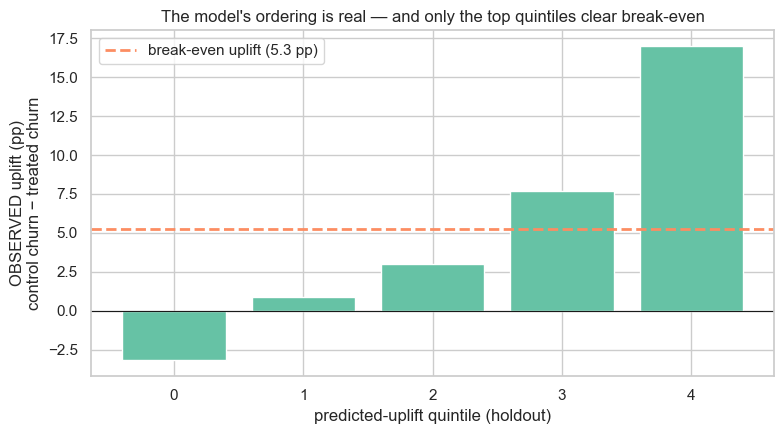

In [11]:
# FIG 2 -- observed uplift by predicted-uplift quintile, vs the break-even line
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(table.index, table["observed uplift"], color="#66c2a5")
ax.axhline(break_even * 100, color="#fc8d62", ls="--", lw=2,
           label=f"break-even uplift ({break_even * 100:.1f} pp)")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("predicted-uplift quintile (holdout)")
ax.set_ylabel("OBSERVED uplift (pp)\ncontrol churn − treated churn")
ax.set_title("The model's ordering is real — and only the top quintiles clear break-even")
ax.legend()
plt.tight_layout()

Two separate readings, both load-bearing:

1. **The ordering is real.** Observed uplift climbs from ≈−3 pp (bottom quintile — those are the sleeping dogs, where the offer *raises* churn) to ≈+17 pp at the top. The model can't see $\tau_i$, but it sorts by it.
2. **The economics has a floor.** A save is worth €180 and a wasted discount costs €9.50, so targeting pays only where $\text{uplift} \times V > D$, i.e. above **5.3 pp**. Only the top two quintiles clear it. "Model says treat" and "economics says treat" are different statements — the threshold belongs to the business, exactly like NB 18 and NB 23 taught for risk.

The last question is the one the retention team actually asks: *given a budget, whom do we call?* We compare three call lists — top-30 % by **uplift**, top-30 % by **risk** (the NB 23 policy), and 30 % at random — and, in god mode, score each against the two-worlds truth with §2's formula.

In [12]:
def true_profit(d, targeted):
    """Realized profit vs a no-offer world: V*(saves - dogs) - D*(treated stayers)."""
    t = np.asarray(targeted, dtype=bool)
    return (V * ((d.y0 == 1) & (d.y1 == 0) & t).sum()
            - V * ((d.y0 == 0) & (d.y1 == 1) & t).sum()
            - D * (t & (d.y1 == 0)).sum())

k = int(0.30 * len(ho))
policies = {
    "top 30% by uplift": np.argsort(-uplift_ho)[:k],
    "top 30% by risk":   np.argsort(-risk_ho)[:k],
    "random 30%":        np.random.default_rng(9).choice(len(ho), k, replace=False),
    "treat everyone":    np.arange(len(ho)),
}
seg_ho = segment(ho)
print(f"{'policy':<18} {'true profit':>12}   {'persuadables reached':>21} {'sleeping dogs hit':>18}")
for name, idx in policies.items():
    sel = np.zeros(len(ho), dtype=bool); sel[idx] = True
    pers = (sel & (seg_ho == "persuadable")).sum() / (seg_ho == "persuadable").sum()
    dogs = (sel & (seg_ho == "sleeping dog")).sum() / (seg_ho == "sleeping dog").sum()
    print(f"{name:<18} {true_profit(ho, sel):>10.0f} EUR   {pers:>21.0%} {dogs:>18.0%}")

policy              true profit    persuadables reached  sleeping dogs hit
top 30% by uplift       24885 EUR                     66%                12%
top 30% by risk         13424 EUR                     52%                22%
random 30%              -4680 EUR                     30%                33%
treat everyone         -12623 EUR                    100%               100%


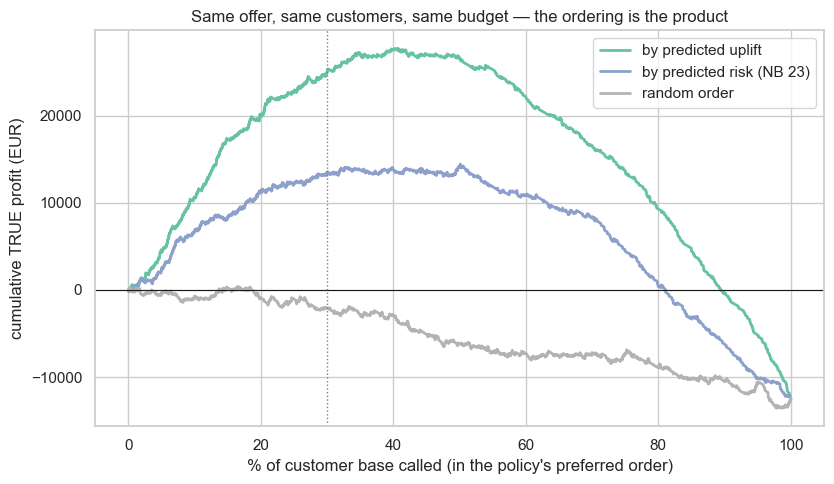

In [13]:
# FIG 3 -- profit as you extend the call list, in each ordering
contrib = (V * (ho.y0 - ho.y1) - D * (1 - ho.y1)).to_numpy()   # SS2's formula per customer
fig, ax = plt.subplots(figsize=(8.5, 5))
frac = np.arange(1, len(ho) + 1) / len(ho)
for label, order, color in [
        ("by predicted uplift", np.argsort(-uplift_ho), "#66c2a5"),
        ("by predicted risk (NB 23)", np.argsort(-risk_ho), "#8da0cb"),
        ("random order", np.random.default_rng(9).permutation(len(ho)), "#b3b3b3")]:
    ax.plot(frac * 100, np.cumsum(contrib[order]), label=label, color=color, lw=2)
ax.axhline(0, color="k", lw=0.8)
ax.axvline(30, color="gray", ls=":", lw=1)
ax.set_xlabel("% of customer base called (in the policy's preferred order)")
ax.set_ylabel("cumulative TRUE profit (EUR)")
ax.set_title("Same offer, same customers, same budget — the ordering is the product")
ax.legend()
plt.tight_layout()

The table and curve say the same three things:

- **Targeting by uplift nearly doubles the risk policy's profit** (≈€25k vs ≈€13k at 30 %): it reaches two-thirds of the persuadables while calling *half as many* sleeping dogs (12 % vs 22 %).
- **Calling everyone loses ~€13k** — a program with a genuinely negative-churn ATE still torches money when 94 % of recipients are sure things, lost causes, or dogs. Averages authorize programs; uplift allocates them.
- The uplift curve **peaks and then falls**: past ~50 % of the base you're paying discounts to sure things and waking dogs. The optimal depth is where the curve turns — which is the break-even threshold from FIG 2 wearing cumulative clothes.

> ⚠️ **What made all of this legitimate is §3.** The T-learner's two models were trained on arms that randomization made comparable. Feed the same estimator last quarter's *targeted* data and it inherits every gram of the selection bias — you'll debug exactly that in 🧪 Exercise 3.

---

### ✋ Quick exercise (~2 min) — how deep should the list go?

Using the quintile table above: which quintiles should Brightloop treat if a save is worth `V = 180` and the discount costs `D = 9.50`? And how does your answer change for a **premium** offer costing €30/stayer aimed at saving a €300 customer?

In [14]:
# ✍️ Your turn 👇
# break-even uplift = D / V for each offer; compare against the quintile table

<details>
<summary>✅ <b>Solution</b></summary>

```python
obs_uplift = table["observed uplift"]          # in pp
for label, d_, v_ in [("current offer", 9.50, 180.0), ("premium offer", 30.0, 300.0)]:
    be = d_ / v_ * 100
    keep = obs_uplift[obs_uplift > be]
    print(f"{label}: break-even {be:.1f} pp -> treat quintiles {sorted(keep.index.tolist())}")
```

Current offer: break-even 5.3 pp → quintiles **3 and 4** (the top 40 %). Premium offer: break-even jumps to **10 pp** → only quintile **4** survives. Note what did *not* enter the calculation: model scores, AUCs, p-values. Once the model has ordered the base, the treatment depth is set by `D/V` — the economics dial the campaign, and a richer offer must be *more* concentrated, not less.
</details>

## 5. No experiment allowed — difference-in-differences

Not everything can be randomized. Mid-year, Brightloop's product team shipped an **in-app concierge** (guided onboarding + proactive check-ins) — but only in the **North** region, starting in **month 7**, because that's where the support team had capacity. A year later, leadership asks the causal question: *did the concierge reduce churn?*

No coin was flipped. North and South differ in ways nobody fully measured, and churn moves seasonally in both. But that structure — **two groups, a before, and an after** — supports one of the oldest tricks in applied economics, **difference-in-differences (DiD)**:

$$\widehat{\tau}_{\text{DiD}} = (\bar y_{N,\text{post}} - \bar y_{N,\text{pre}}) - (\bar y_{S,\text{post}} - \bar y_{S,\text{pre}})$$

South's before→after change estimates what North *would have done* untreated (seasonality, market shocks); subtracting it removes every difference that is **fixed per region** and every shock that is **common to both**. What survives is the launch. The price of admission is the **parallel-trends assumption**: absent the concierge, the two regions' churn would have moved in parallel. Untestable after month 7 — but the *pre*-period is a witness you should always interrogate.

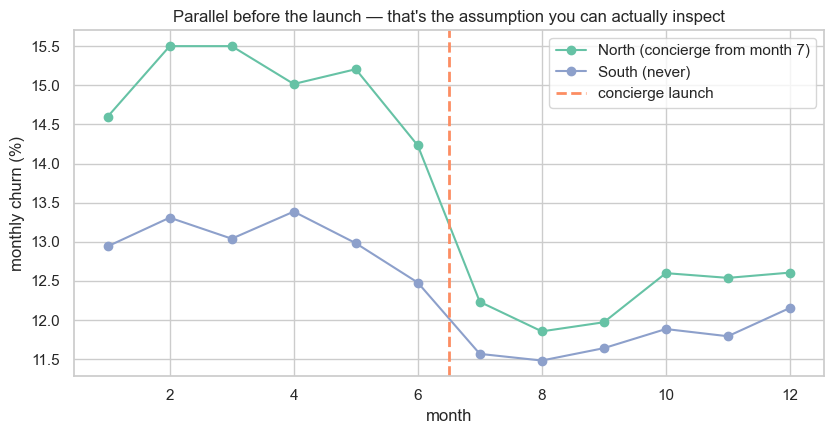

In [15]:
# monthly churn rate per region; concierge live in North from month 7
rngd = np.random.default_rng(5)
months = np.arange(1, 13)
season = 0.010 * np.sin(months / 12 * 2 * np.pi) + rngd.normal(0, 0.002, 12)
north = 0.145 + season + np.where(months >= 7, -0.015, 0) + rngd.normal(0, 0.0025, 12)
south = 0.125 + season + rngd.normal(0, 0.0025, 12)

# FIG 4 -- the whole method is visible in one picture
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(months, north * 100, "-o", color="#66c2a5", label="North (concierge from month 7)")
ax.plot(months, south * 100, "-o", color="#8da0cb", label="South (never)")
ax.axvline(6.5, color="#fc8d62", ls="--", lw=2, label="concierge launch")
ax.set_xlabel("month"); ax.set_ylabel("monthly churn (%)")
ax.set_title("Parallel before the launch — that's the assumption you can actually inspect")
ax.legend(); plt.tight_layout()

In [16]:
pre, post = months <= 6, months >= 7
did = (north[post].mean() - north[pre].mean()) - (south[post].mean() - south[pre].mean())

cells = pd.DataFrame(
    {"pre (m1-6)": [north[pre].mean(), south[pre].mean()],
     "post (m7-12)": [north[post].mean(), south[post].mean()]},
    index=["North", "South"]).mul(100).round(2)
print(cells, "\n")
print(f"DiD estimate: {did * 100:+.2f} pp per month  (simulation truth: -1.50)")

# placebo: pretend the launch happened in month 4 -- inside the pre-period,
# where the true effect is zero by construction. A real method should find ~0.
fake_pre, fake_post = months <= 3, (months >= 4) & (months <= 6)
placebo = ((north[fake_post].mean() - north[fake_pre].mean())
           - (south[fake_post].mean() - south[fake_pre].mean()))
print(f"placebo 'launch' at month 4: {placebo * 100:+.2f} pp  -- consistent with zero, good")

       pre (m1-6)  post (m7-12)
North       15.01         12.30
South       13.02         11.75 

DiD estimate: -1.44 pp per month  (simulation truth: -1.50)
placebo 'launch' at month 4: -0.23 pp  -- consistent with zero, good


Four cell means, one subtraction of subtractions, and the estimate lands on **−1.44 pp** against a planted truth of −1.50. Notice what DiD did *not* need: no model of churn, no customer features, no propensities — just the panel structure and the parallel-trends leap of faith. That's both its power and its fragility:

- **It absorbs** any fixed North/South difference (the 2 pp level gap never entered the estimate) and any common shock (the seasonal wave subtracted itself out).
- **It breaks silently** if the treated region was *trending differently* before launch — e.g. if North got the concierge *because* its churn was drifting up. That's why the placebo test and a hard stare at the pre-period lines are not optional garnish; they are the method. (Stretch B turns this into a proper event-study.)
- One subtlety worth carrying: DiD estimates the effect **on the treated region**, under that region's conditions — the concierge's effect in South is extrapolation.

---

### ✋ Quick exercise (~2 min) — DiD by hand

Brightloop also rolled out **priority support** to its Premium plan (and only that plan) in Q3. Quarterly churn:

| | Q2 (before) | Q3 (after) |
|---|---|---|
| Premium (got it) | 9.0 % | 8.2 % |
| Standard (never) | 14.0 % | 14.6 % |

Compute the DiD estimate. Then: a colleague objects that *"Premium customers churn less anyway, the comparison is unfair."* Does that objection bite?

In [17]:
# ✍️ Your turn 👇
# did = (premium_after - premium_before) - (standard_after - standard_before)

<details>
<summary>✅ <b>Solution</b></summary>

```python
did_hand = (0.082 - 0.090) - (0.146 - 0.140)
print(f"DiD: {did_hand * 100:+.1f} pp -- priority support cut Premium churn by ~1.4 pp/quarter")
```

Premium moved −0.8 pp while Standard drifted +0.6 pp; the difference of differences is **−1.4 pp**. The colleague's objection does *not* bite: a fixed "Premium churns less" gap is exactly what the first differencing removes — DiD compares *changes*, not levels. The objection that **would** bite: "Premium churn was already improving in Q1 while Standard's wasn't" — a differential *trend*. Levels are free; trends are the assumption.
</details>

## 6. Adjusting the targeted quarter — and the confounder you can't see

Back to last quarter's mess one final time. Suppose there had been no RCT and no clean rollout — just the risk-targeted campaign data from §1. Is it salvageable?

Sometimes. The key fact about that campaign: the risk list came from **the old model's score**, which is a function of *observed* features (usage, tickets, tenure, promo signup) — and coverage was patchy, so at every score level some customers got the offer and some didn't. Together that gives us the two conditions every adjustment method needs:

1. **Ignorability** — treatment depended only on things we *measured* (given the features, who got treated is as good as random);
2. **Overlap** — no kind of customer was treated with probability 0 or 1 (we have both worlds represented *within* every neighbourhood of the feature space).

Under those two, "compare like with like" becomes a valid strategy. Two classic implementations:

- **Regression adjustment:** fit churn on features **plus** treatment; the model compares treated vs untreated *at the same features*, then average the modelled effect over the book.
- **IPW** (inverse propensity weighting): fit the *treatment* on features to get each customer's propensity $e(x)$, then re-weight — under-treated kinds of customers count for more in the treated average, over-treated kinds for more in the control average — rebuilding the balanced experiment the team never ran.

In [18]:
X = obs[FEATURES].to_numpy()

# --- regression adjustment ---
out = LogisticRegression(max_iter=2000).fit(
    np.column_stack([X, obs.treated]), obs.churned)
adj = (out.predict_proba(np.column_stack([X, np.ones(len(obs))]))[:, 1]
       - out.predict_proba(np.column_stack([X, np.zeros(len(obs))]))[:, 1]).mean()

# --- IPW ---
prop = LogisticRegression(max_iter=2000).fit(X, obs.treated)
e = prop.predict_proba(X)[:, 1].clip(0.02, 0.98)
w1, w0 = obs.treated / e, (1 - obs.treated) / (1 - e)
ipw = (w1 * obs.churned).sum() / w1.sum() - (w0 * obs.churned).sum() / w0.sum()

print(f"naive                 : {naive * 100:+.2f} pp")
print(f"regression adjustment : {adj * 100:+.2f} pp")
print(f"IPW                   : {ipw * 100:+.2f} pp")
print(f"RCT / truth (ATE)     : {est * 100:+.2f} / {true_ate * 100:+.2f} pp")

naive                 : +1.85 pp
regression adjustment : -1.53 pp
IPW                   : -1.89 pp
RCT / truth (ATE)     : -4.27 / -3.04 pp


Adjustment turned the **+1.85 pp** lie into a **−1.5 to −1.9 pp** estimate — the sign is right and most of the selection bias is gone, though a residual remains (our simple logistic models don't perfectly capture either the outcome or the steep treatment rule; Stretch C's doubly-robust estimator with cross-fitted boosted models closes most of the remaining gap). For a decision as coarse as *"keep or kill the program"*, the adjusted analysis already lands on the right side.

Now the punchline this section exists for. Everything above leaned on ignorability: *treatment depended only on things we measured.* Suppose instead that agents, working down the same risk list, **also read the support-call notes** — and preferentially targeted customers who *sounded* angry. Anger predicts churn but lives in **no column of our data** (it's the `rng.normal(0, 0.35)` inside `z0` — go look). Rerun the exact same machinery on that quarter:

In [19]:
# the hidden-confounder quarter: same customers, but assignment also saw the
# unmeasured "anger" component of true risk
z_obs_o = (-1.15 - 0.045 * obs.usage + 0.38 * obs.tickets
           - 0.012 * obs.tenure + 0.55 * obs.promo_signup)
hidden = np.log(obs.p0 / (1 - obs.p0)) - z_obs_o          # the part no model has
score_h = sigmoid(z_obs_o + 2.0 * hidden)
rng_h = np.random.default_rng(45)
p_h = sigmoid(10 * (score_h - np.quantile(score_h, 0.60))).clip(0.05, 0.95)
obs_h = obs.copy()
obs_h["treated"] = (rng_h.random(len(obs_h)) < p_h).astype(int)
obs_h["churned"] = np.where(obs_h.treated == 1, obs_h.y1, obs_h.y0)

out_h = LogisticRegression(max_iter=2000).fit(
    np.column_stack([X, obs_h.treated]), obs_h.churned)
adj_h = (out_h.predict_proba(np.column_stack([X, np.ones(len(obs_h))]))[:, 1]
         - out_h.predict_proba(np.column_stack([X, np.zeros(len(obs_h))]))[:, 1]).mean()

print(f"regression adjustment, hidden-confounder quarter: {adj_h * 100:+.2f} pp")
print(f"truth is still                                  : {true_ate * 100:+.2f} pp")

regression adjustment, hidden-confounder quarter: +1.35 pp
truth is still                                  : -3.04 pp


**+1.4 pp — the sign is wrong again.** Same estimator, same features, same amount of statistical sophistication; the only change is *why* people got treated. The adjustment controlled for everything it could see, removed the part of the bias that lived in those columns — and confidently reported that a helpful offer hurts, because the rest of the bias walked in through the column that isn't there. Nothing in the output warns you. The code that produced a usable answer in the previous cell and a harmful one here is *identical*.

That asymmetry deserves to be stated as the section's law:

> ⚠️ **Adjustment is an assumption wearing a method's clothes.** Regression adjustment, IPW, matching, and their doubly-robust descendants all deliver exactly this contract: *causal effects, provided treatment depended only on measured variables.* The data cannot certify that proviso — you argue it from knowledge of how the treatment was actually assigned. This is why §3's randomized quarter is not a luxury: a coin flip is the only assignment mechanism that is measured *by definition*. When you inherit observational data, your first question is never "which estimator?" — it is **"who decided who got treated, and what did they know?"**

---

### ✋ Quick exercise (~2 min) — which way does the ghost push?

For each scenario, say whether a naive treated-vs-untreated comparison **overstates** or **understates** the treatment's benefit, and name the lurking variable:

1. A gym's personal-training add-on, bought voluntarily by members — outcome: weight loss.
2. NB 26's predictive maintenance: mechanics service the machines that *sound* worst — outcome: breakdowns.
3. An optional "power user" webinar for new Brightloop signups — outcome: 90-day retention.

In [20]:
# ✍️ Your turn 👇  (reasoning exercise -- write your three answers as comments)
# 1.
# 2.
# 3.

<details>
<summary>✅ <b>Solution</b></summary>

```python
print("1. OVERSTATES  - motivated members self-select into training (motivation -> weight loss anyway)")
print("2. UNDERSTATES - the serviced machines were the sickest (like SS1's risk-targeted discounts)")
print("3. OVERSTATES  - engaged users attend webinars; engagement was retaining them regardless")
```

The compass that never fails: ask *who ended up treated*, then ask how the treated group's **no-treatment outcome** ($y_0$) compares with the untreated group's. Treatment flowing toward the **worst** cases (2) biases the naive number *against* the treatment; treatment flowing toward the **best or most motivated** cases (1, 3) biases it *in favour*. Selection bias is just $\mathbb{E}[y_0|T{=}1] - \mathbb{E}[y_0|T{=}0]$ — §2's decomposition, every time.
</details>

## 7. What real causal systems add (honest section)

Everything above is the load-bearing 80 %. What production causal work layers on top:

- **Variance reduction.** A2's CUPED applies verbatim to retention RCTs (pre-period churn propensity as the covariate) — same test, tighter CI, smaller required quarters.
- **Better uplift learners.** The T-learner is the honest baseline. **S-learners** (one model, treatment as a feature) shrink uplift toward zero when effects are small (🧪 Exercise 2); **X-/R-/DR-learners** combine outcome and propensity models for better efficiency, especially off-RCT. Libraries: `causalml` (uplift-native, Qini tooling), `econml` (Microsoft's CATE estimators), `dowhy` (assumption graphs + refutation tests).
- **Doubly-robust estimation.** AIPW combines regression adjustment and IPW so that *either* model being right suffices — with cross-fitting, it's the modern default for observational effects (Stretch C builds it in ~15 lines).
- **Sharper quasi-experiments.** Event-study DiD with leads and lags (Stretch B), **synthetic control** (weight several donor regions to mimic the treated one), **regression discontinuity** (was there a hard score cutoff? A3's approval threshold is one), **instrumental variables** for when even ignorability is hopeless but a lottery-like nudge exists (encouragement designs).
- **Sensitivity analysis.** You can't test for hidden confounders, but you can ask *how strong* one would have to be to erase the estimate (Rosenbaum bounds, E-values) — turning §6's cliff into a graded confidence statement.
- **Always-on experimentation.** The mature end-state for retention: every campaign permanently keeps a small randomized holdout (5–10 %), so uplift models retrain on clean data each quarter and the ROI report writes itself. One line of budget, immunity from this notebook's §1 forever.

## 🧠 The story in one screen

| # | The move | The number that carries it |
|---|---|---|
| 1 | Last quarter's report: naive comparison on a risk-targeted campaign | "+1.8 pp — the offer backfired" |
| 2 | Potential outcomes decompose it: effect + selection | −5.4 pp real effect **+7.3 pp selection bias** |
| 2 | Four segments, priced: persuadable / sure thing / lost cause / sleeping dog | +€170.50 / −€9.50 / €0 / **−€180** |
| 3 | Randomize this quarter → selection term dies by construction | −4.3 ± 1.5 pp, selection −1.4 (noise) |
| 4 | T-learner on the RCT: order customers by *reaction*, not risk | observed uplift −3 → +17 pp across quintiles |
| 4 | Break-even uplift D/V sets the treatment depth | 5.3 pp → treat top 40 % |
| 4 | Policy race at 30 % budget | uplift **€25k** vs risk €13k vs treat-all **−€13k** |
| 5 | DiD for the un-randomizable rollout + placebo | −1.44 pp (truth −1.50); placebo −0.23 |
| 6 | Adjustment works on measured targeting… | +1.9 → −1.5/−1.9 pp (truth −3.0) |
| 6 | …and dies silently on unmeasured targeting | **+1.4 pp — wrong sign, no warning of any kind** |

## 🧪 Practice exercises

### Exercise 1 — ⭐ The decomposition, twice

Verify §2's identity — `naive = ATT + selection bias` — holds *exactly* on the hidden-confounder quarter `obs_h` as well. Then compare the two quarters' selection-bias terms. Which quarter's targeting was more aggressive, and how can you tell *without* god mode?

In [21]:
# Starter
# naive_h, att_h (needs y0/y1), sel_h = E[y0|T=1] - E[y0|T=0] ... on obs_h

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
t1h, t0h = obs_h[obs_h.treated == 1], obs_h[obs_h.treated == 0]
naive_h = t1h.churned.mean() - t0h.churned.mean()
att_h = (t1h.y1 - t1h.y0).mean()
sel_h = t1h.y0.mean() - t0h.y0.mean()
print(f"hidden quarter: naive {naive_h*100:+.2f} = ATT {att_h*100:+.2f} + selection {sel_h*100:+.2f}")
print(f"visible quarter had selection {sel_bias*100:+.2f} pp")
```

The identity holds to the last decimal in both quarters — it's algebra, not statistics. The hidden quarter's selection term is *larger*: scoring on the anger signal (a direct component of true risk) concentrates treatment on churners even more effectively than the feature-based model did. Without god mode you can't compute `sel`, but you *can* see its fingerprint: compare the treated group's **pre-treatment covariates** (tickets, usage, tenure) against the untreated group's. Wildly unbalanced covariates = aggressive targeting = a naive number you should refuse to read out loud.
</details>

### Exercise 2 — ⭐⭐ The S-learner vs the folk wisdom

The T-learner's simplest rival fits **one** model with `treated` as just another feature, then predicts each holdout customer twice — `treated=1` vs `treated=0` — and subtracts. The folk wisdom (you'll hear it in every uplift talk) says the S-learner *shrinks effects toward zero*, because the tree only splits on `treated` when that split earns its keep. Build it on the same RCT training set and put the claim on trial: correlation with true uplift, mean predicted uplift vs the truth, and true profit of its top-30 % policy. Does the folk rule hold here?

In [22]:
# Starter
# m_s = HistGradientBoostingClassifier(random_state=0).fit(tr[FEATURES + ["treated"]], tr.churned)
# uplift_s = predict at treated=0 minus predict at treated=1 ... on ho

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
m_s = HistGradientBoostingClassifier(random_state=0).fit(
    tr[FEATURES + ["treated"]], tr.churned)
ho0 = ho[FEATURES].assign(treated=0)[FEATURES + ["treated"]]
ho1 = ho[FEATURES].assign(treated=1)[FEATURES + ["treated"]]
uplift_s = m_s.predict_proba(ho0)[:, 1] - m_s.predict_proba(ho1)[:, 1]

sel_s = np.zeros(len(ho), dtype=bool)
sel_s[np.argsort(-uplift_s)[:k]] = True
print(f"corr with true uplift: S {np.corrcoef(uplift_s, true_uplift_ho)[0,1]:.2f} "
      f"vs T {np.corrcoef(uplift_ho, true_uplift_ho)[0,1]:.2f}")
print(f"mean predicted uplift: S {uplift_s.mean()*100:+.1f} pp vs T {uplift_ho.mean()*100:+.1f} pp "
      f"(true {true_uplift_ho.mean()*100:+.1f} pp)")
sel_t = np.zeros(len(ho), dtype=bool)
sel_t[np.argsort(-uplift_ho)[:k]] = True
print(f"top-30% policy profit: S {true_profit(ho, sel_s):,.0f} vs T {true_profit(ho, sel_t):,.0f} EUR")
```

Verdict: **the folk rule loses this trial.** On this data the S-learner *wins on every count* — higher correlation with the truth (≈0.65 vs 0.55), a mean uplift *closer* to the true +3.1 pp, and a top-30 % policy worth several thousand euros more. The reason is variance, not bias: the two arms share almost all of their churn structure, and the S-learner learns that shared structure once from 6,000 pooled rows, while the T-learner learns it twice from 3,000 rows each and then *subtracts two independently noisy estimates*. The shrinkage failure mode is real — it bites when the treated share is small or effects are tiny relative to the tree's regularization, where `treated` never earns a split — but it is a *tendency to check for*, not a law. The course-wide lesson applies to method folklore too: measure, don't recite. (And notice what made the measurement possible: god mode. In production you'd compare learners on the observed quintile table and Qini curve, Stretch A.)
</details>

### Exercise 3 — ⭐⭐ Debug me 🐞: the uplift model that killed a working program

A colleague skipped the RCT ("we have last year's campaign data!") and trained the T-learner on the **hidden-confounder quarter**. Their report: *"Mean predicted uplift is ≈**−1.3 pp** — the offers appear to mildly *increase* churn. Recommend cancelling the retention program."* Reproduce their number, find the flaw, and say what the correct program-level verdict is.

In [23]:
# Starter -- their exact pipeline (it runs without error; that's the point)
m_tb = HistGradientBoostingClassifier(random_state=0).fit(
    obs_h.loc[obs_h.treated == 1, FEATURES], obs_h.loc[obs_h.treated == 1, "churned"])
m_cb = HistGradientBoostingClassifier(random_state=0).fit(
    obs_h.loc[obs_h.treated == 0, FEATURES], obs_h.loc[obs_h.treated == 0, "churned"])
uplift_biased = m_cb.predict_proba(ho[FEATURES])[:, 1] - m_tb.predict_proba(ho[FEATURES])[:, 1]
print(f"mean predicted uplift: {uplift_biased.mean() * 100:+.1f} pp -> 'cancel the program'??")

mean predicted uplift: -1.3 pp -> 'cancel the program'??


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
print(f"biased T-learner mean : {uplift_biased.mean()*100:+.1f} pp")
print(f"honest T-learner mean : {uplift_ho.mean()*100:+.1f} pp")
print(f"RCT program-level ATE : {est*100:+.2f} pp -> the program WORKS")
print(f"corr(biased, truth) = {np.corrcoef(uplift_biased, true_uplift_ho)[0,1]:.2f} "
      f"-- the RANKING even survives!")
```

The flaw is §6 wearing an ML costume. In that quarter, treatment chased the unmeasured anger signal — so **at every feature value x**, the treated customers were secretly angrier (higher true risk) than the untreated ones. `m_tb` therefore learns "churn-with-offer" *too high* and `m_cb` learns "churn-without" *too low*; their difference — the predicted uplift — is dragged down across the board, all the way below zero. It's a **level** poisoning: the ranking survives essentially intact (corr ≈0.56, vs 0.55 for the honest model), but the *magnitude* is fiction, and the colleague's verdict used the magnitude. Correct verdict: the RCT already measured the program at **−4.3 pp** — it earns money when targeted (§4). The general lesson: *train uplift on randomized data, or on observational data only after the §6 interrogation — and never let a break-even rule read magnitudes from a model whose level you can't trust.*
</details>

### Exercise 4 — ⭐⭐ A budget, a list, a number

The retention team can make **1,200 calls** into the 6,000-customer holdout. Compare three list-building rules — top-1200 by uplift, top-1200 by risk, and "everyone above break-even, then highest-uplift first, capped at 1,200" — on true profit and on how many sleeping dogs each wakes. Does the break-even cap change anything at this budget?

In [24]:
# Starter
budget = 1200
# rule A: np.argsort(-uplift_ho)[:budget]
# rule B: np.argsort(-risk_ho)[:budget]
# rule C: among uplift_ho > D/V, take the highest-uplift `budget` (or fewer)

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
budget = 1200
rule_a = np.argsort(-uplift_ho)[:budget]
rule_b = np.argsort(-risk_ho)[:budget]
elig = np.where(uplift_ho > D / V)[0]
rule_c = elig[np.argsort(-uplift_ho[elig])][:budget]

for name, idx in [("A top-uplift", rule_a), ("B top-risk", rule_b), ("C break-even capped", rule_c)]:
    s = np.zeros(len(ho), dtype=bool); s[idx] = True
    dogs = (s & (seg_ho == "sleeping dog")).sum()
    print(f"{name:20s}: calls {s.sum():>5}  profit {true_profit(ho, s):>9,.0f} EUR  dogs woken {dogs}")
```

At a 1,200-call budget (20 % of the base), rules A and C pick **the same list** — the 1,200th-best uplift is still above the 5.3 pp break-even, so the cap never binds. The cap matters at *large* budgets: it's the rule that stops FIG 3's green curve at its peak instead of riding it downhill. Top-risk trails by thousands of euros and wakes more dogs — with the *same* model family and the *same* features, the only difference being what the model was asked to predict. The business lesson: capacity constraints change *how deep* you go, never *which ordering* you use.
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ The Qini curve, and error bars on a policy

FIG 3 used god mode. Build the production version from **observed** holdout outcomes only: the **uplift curve** — for each targeting depth $k$, (control churn − treated churn among the top-$k$) × $k$ — i.e. estimated *saves* as the list deepens; add the random-targeting diagonal (the "Qini" baseline). Then bootstrap the holdout (resample rows, 500 reps) to put a 95 % CI on the *estimated* profit of the 30 % uplift policy: uplift·V − (1−churn)·D summed over the treated. Does the CI's message match the god-mode ranking of §4?

In [25]:
# Starter -- sketch:
# order = np.argsort(-uplift_ho); walk k over a grid of depths
# saves_hat(k) = (churn_c(topk) - churn_t(topk)) * k      [within-topk arms are fair: RCT]
# bootstrap: rows = rng.integers(0, len(ho), len(ho)); recompute policy profit estimate

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
order = np.argsort(-uplift_ho)
ks = np.arange(150, len(ho) + 1, 150)
saves = []
for kk in ks:
    top = ho.iloc[order[:kk]]
    saves.append((top.loc[top.treated == 0, "churned"].mean()
                  - top.loc[top.treated == 1, "churned"].mean()) * kk)
plt.figure(figsize=(7.5, 4.2))
plt.plot(ks / len(ho) * 100, saves, color="#66c2a5", lw=2, label="uplift ordering (observed)")
overall = (ho.loc[ho.treated == 0, "churned"].mean() - ho.loc[ho.treated == 1, "churned"].mean())
plt.plot(ks / len(ho) * 100, overall * ks, ls=":", color="#b3b3b3", label="random ordering")
plt.xlabel("% targeted"); plt.ylabel("estimated customers saved")
plt.legend(); plt.title("Uplift (Qini-style) curve -- no god mode required"); plt.tight_layout()

rngb = np.random.default_rng(0)
profits = []
for _ in range(500):
    rows = rngb.integers(0, len(ho), len(ho))
    b = ho.iloc[rows].reset_index(drop=True); u_b = uplift_ho[rows]
    top = np.argsort(-u_b)[:int(0.3 * len(b))]
    tb = b.iloc[top]
    upl_hat = (tb.loc[tb.treated == 0, "churned"].mean()
               - tb.loc[tb.treated == 1, "churned"].mean())
    stay_hat = 1 - tb.loc[tb.treated == 1, "churned"].mean()
    profits.append(len(top) * (upl_hat * V - stay_hat * D))
lo, hi = np.percentile(profits, [2.5, 97.5])
print(f"estimated 30% uplift-policy profit: 95% CI [{lo:,.0f}, {hi:,.0f}] EUR")
```

The observed curve bends exactly like FIG 3's god-mode one — steep early, flat past ~50 % — which is the point: **the RCT lets you draw the money curve without ever seeing a counterfactual.** The bootstrap CI is wide — roughly ±€12k around its centre; uplift differences are noisy, §4 warned you — but comfortably positive, and safely above a same-sized bootstrap of the risk policy if you run one. Decision-grade, not decimal-grade.
</details>

### Stretch exercise B — ⭐⭐⭐ The event study — DiD with its cards face up

Upgrade §5 to the modern presentation: for each month $m$, compute $\delta_m = (\text{north}_m - \bar{\text{north}}_{\text{pre}}) - (\text{south}_m - \bar{\text{south}}_{\text{pre}})$ and plot the twelve coefficients with a launch line. The pre-launch $\delta$s are your parallel-trends evidence *in public*. Add a permutation placebo: rerun §5's DiD pretending the launch happened at every month 3–6, and compare the real estimate against that distribution.

In [26]:
# Starter -- sketch:
# delta_m per month against PRE means; scatter/stem plot, vline at 6.5
# placebo: for fake in (3,4,5,6): did with pre=months<fake, post=fake..6

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
delta = (north - north[pre].mean()) - (south - south[pre].mean())
plt.figure(figsize=(7.5, 4))
plt.stem(months, delta * 100)
plt.axvline(6.5, color="#fc8d62", ls="--"); plt.axhline(0, color="k", lw=0.8)
plt.xlabel("month"); plt.ylabel("event-study coefficient (pp)")
plt.title("Flat then a step down: leads testify, lags measure"); plt.tight_layout()

placebos = []
for fake in (3, 4, 5, 6):
    fp, fq = months < fake, (months >= fake) & (months <= 6)
    placebos.append((north[fq].mean() - north[fp].mean())
                    - (south[fq].mean() - south[fp].mean()))
print("placebo DiDs (pp):", np.round(np.array(placebos) * 100, 2))
print(f"real DiD          : {did * 100:+.2f} pp -- outside the placebo range")
```

The picture is the argument: pre-launch coefficients rattle around zero (that *is* parallel trends, shown rather than assumed), then step down by ~1.5 pp and stay there. The placebo DiDs cluster within ±0.4 pp — the real −1.44 sits far outside their range, which is the honest, small-sample way to say "significant" here. When a real rollout's leads *aren't* flat, this plot is what saves you from publishing a trend as a treatment effect.
</details>

### Stretch exercise C — ⭐⭐⭐ Doubly robust, cross-fitted — closing §6's gap

§6's simple adjustments recovered −1.5 to −1.9 pp of the true −3.0. Build **AIPW**: cross-fit (2 folds) an outcome model pair and a propensity model, all `HistGradientBoostingClassifier`, and average the influence function $\hat\mu_1(x) - \hat\mu_0(x) + \tfrac{T(y - \hat\mu_1)}{e(x)} - \tfrac{(1-T)(y - \hat\mu_0)}{1 - e(x)}$ on the *visible*-targeting quarter `obs`. Report the estimate ± 1.96·SE. Then feed it `obs_h` and confirm that no amount of doubly-robust machinery survives a hidden confounder.

In [27]:
# Starter -- sketch:
# for (fit, eval) in the two fold pairs:
#     e(x), mu1(x), mu0(x) trained on `fit`, influence values psi on `eval`
# ATE_hat = psi.mean(); SE = psi.std() / sqrt(n)

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def aipw(frame):
    X_, T_, Y_ = frame[FEATURES].to_numpy(), frame.treated.to_numpy(), frame.churned.to_numpy()
    n = len(frame); half = n // 2
    psi = np.zeros(n)
    for a, b in [(slice(0, half), slice(half, n)), (slice(half, n), slice(0, half))]:
        e_m = HistGradientBoostingClassifier(random_state=0).fit(X_[a], T_[a])
        m1 = HistGradientBoostingClassifier(random_state=0).fit(X_[a][T_[a] == 1], Y_[a][T_[a] == 1])
        m0 = HistGradientBoostingClassifier(random_state=0).fit(X_[a][T_[a] == 0], Y_[a][T_[a] == 0])
        e_ = e_m.predict_proba(X_[b])[:, 1].clip(0.03, 0.97)
        mu1, mu0 = m1.predict_proba(X_[b])[:, 1], m0.predict_proba(X_[b])[:, 1]
        psi[b] = (mu1 - mu0 + T_[b] * (Y_[b] - mu1) / e_
                  - (1 - T_[b]) * (Y_[b] - mu0) / (1 - e_))
    return psi.mean(), 1.96 * psi.std() / np.sqrt(n)

for label, frame in [("visible targeting", obs), ("hidden confounder", obs_h)]:
    m, w = aipw(frame)
    print(f"AIPW, {label:18s}: {m * 100:+.2f} pp ± {w * 100:.2f}   (truth {true_ate * 100:+.2f})")
```

On the visible-targeting quarter, AIPW lands within a fraction of a point of the truth (≈**−2.7 pp**) — the flexible nuisance models capture what §6's logistics missed, and cross-fitting keeps the flexibility from leaking into overfitting. Note the honest price tag: the CI is ±3 pp — 8,000 rows of observational data buys you the *sign*, not the second decimal. On the hidden quarter the estimate lands at ≈+1.7 pp — §6's wrong sign again, now delivered with doubly-robust confidence: doubly robust means *either model may be wrong*, not *the assignment may depend on the unmeasured*. There is no estimator-shaped exit from §6's law.
</details>

## 🎁 Bonus mini-project — the retention decision memo

Write the one-pager Brightloop's CMO should actually receive. It must answer, with numbers from this notebook, and *naming which quarter's data supports each claim*:

1. **Did last quarter's campaign work?** (Which analysis is admissible; what the naive report got wrong.)
2. **Should the program continue, and at what depth?** (The break-even logic, the 30 %-budget policy comparison, expected € per quarter.)
3. **Did the concierge rollout earn its keep?** (The DiD result — and its one untestable assumption, stated in one sentence a CMO can evaluate.)
4. **The standing order for next year:** the permanent 10 % randomized holdout — its cost this quarter (offers withheld from ~persuadables in the holdout) against what it buys (every future model trains on clean data; every future report is §3, never §1).

Grading yourself: every number in your memo should be traceable to a cell above, and every causal claim should name its design — *randomized*, *diff-in-diff*, or *adjusted-observational (assumption: measured targeting)*. If a sentence can't name its design, it doesn't go in the memo.

## ✅ Self-assessment checklist

- [ ] I can decompose a naive treated-vs-untreated gap into ATT + selection bias, and compute both terms when potential outcomes are available.
- [ ] I can name and **price** the four uplift segments for a given `V` and `D`, and explain why "target the riskiest" systematically buys lost causes and sleeping dogs.
- [ ] I can explain what randomization does to the selection term — *by construction, not by assumption* — and check it numerically.
- [ ] I can fit a T-learner, validate it with an observed uplift-by-quintile table, and set the targeting depth from the break-even uplift `D/V`.
- [ ] I can compute a DiD estimate from four cell means, state parallel trends precisely, and run a placebo test.
- [ ] I can say when regression adjustment / IPW are trustworthy (measured assignment + overlap) and demonstrate how an unmeasured confounder defeats them *silently*.
- [ ] I know which question needs which design — and that "who decided who got treated?" comes before "which estimator?".

## 🚀 Where next

- **NB 23** is the economic chassis this notebook bolted causality onto — reread its §4 caveat now that you can *compute* the thing it warned about.
- **A2** for everything this notebook assumed about running the RCT well: MDE before launch, CUPED for tighter CIs, peeking discipline.
- **A3 §6** is this notebook's sibling disease in credit: selective labels are selection bias where *the outcome's existence* is what got targeted.
- Libraries when the by-hand versions earn their keep: `causalml`, `econml`, `dowhy` (§7) — the concepts here are exactly their vocabulary.